KL散度=相对熵=交叉熵-熵
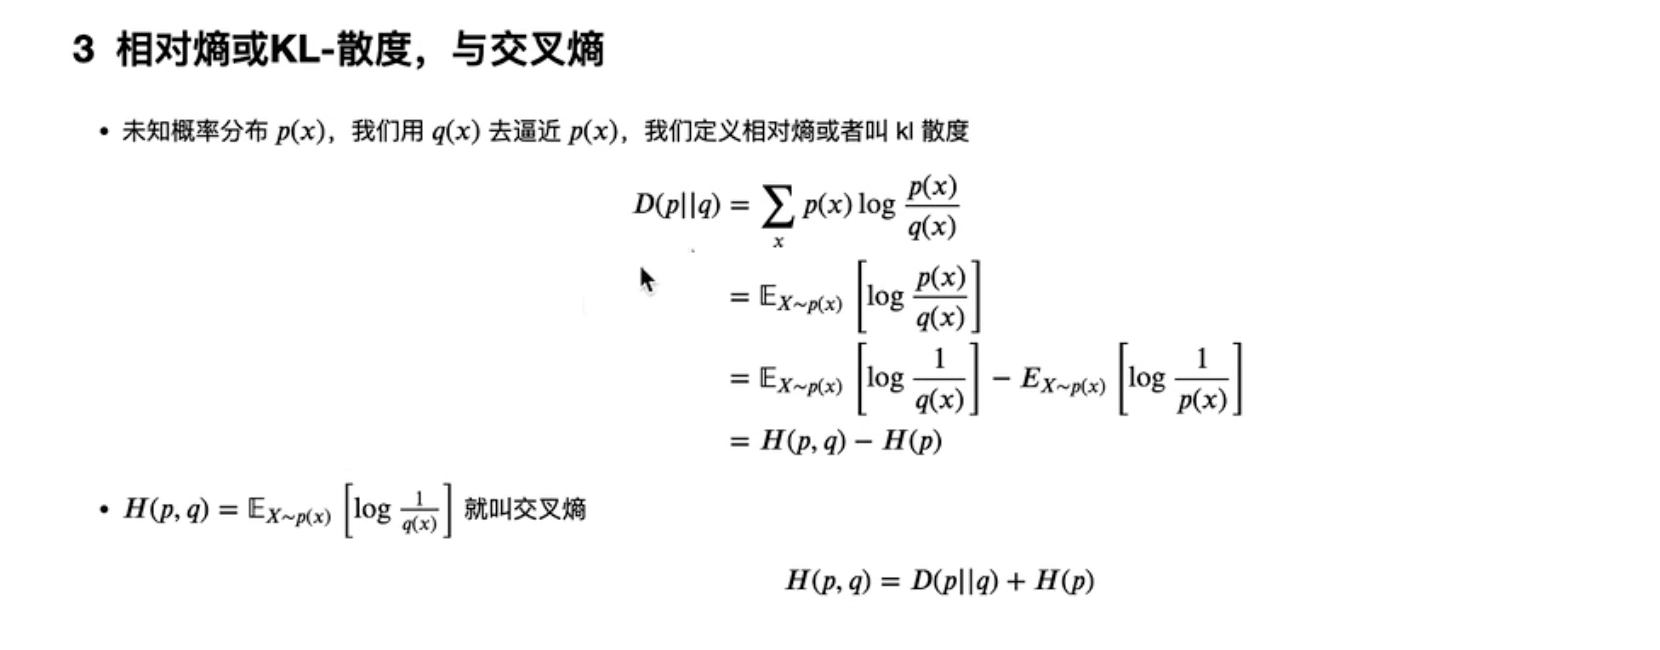

# 离散型变量
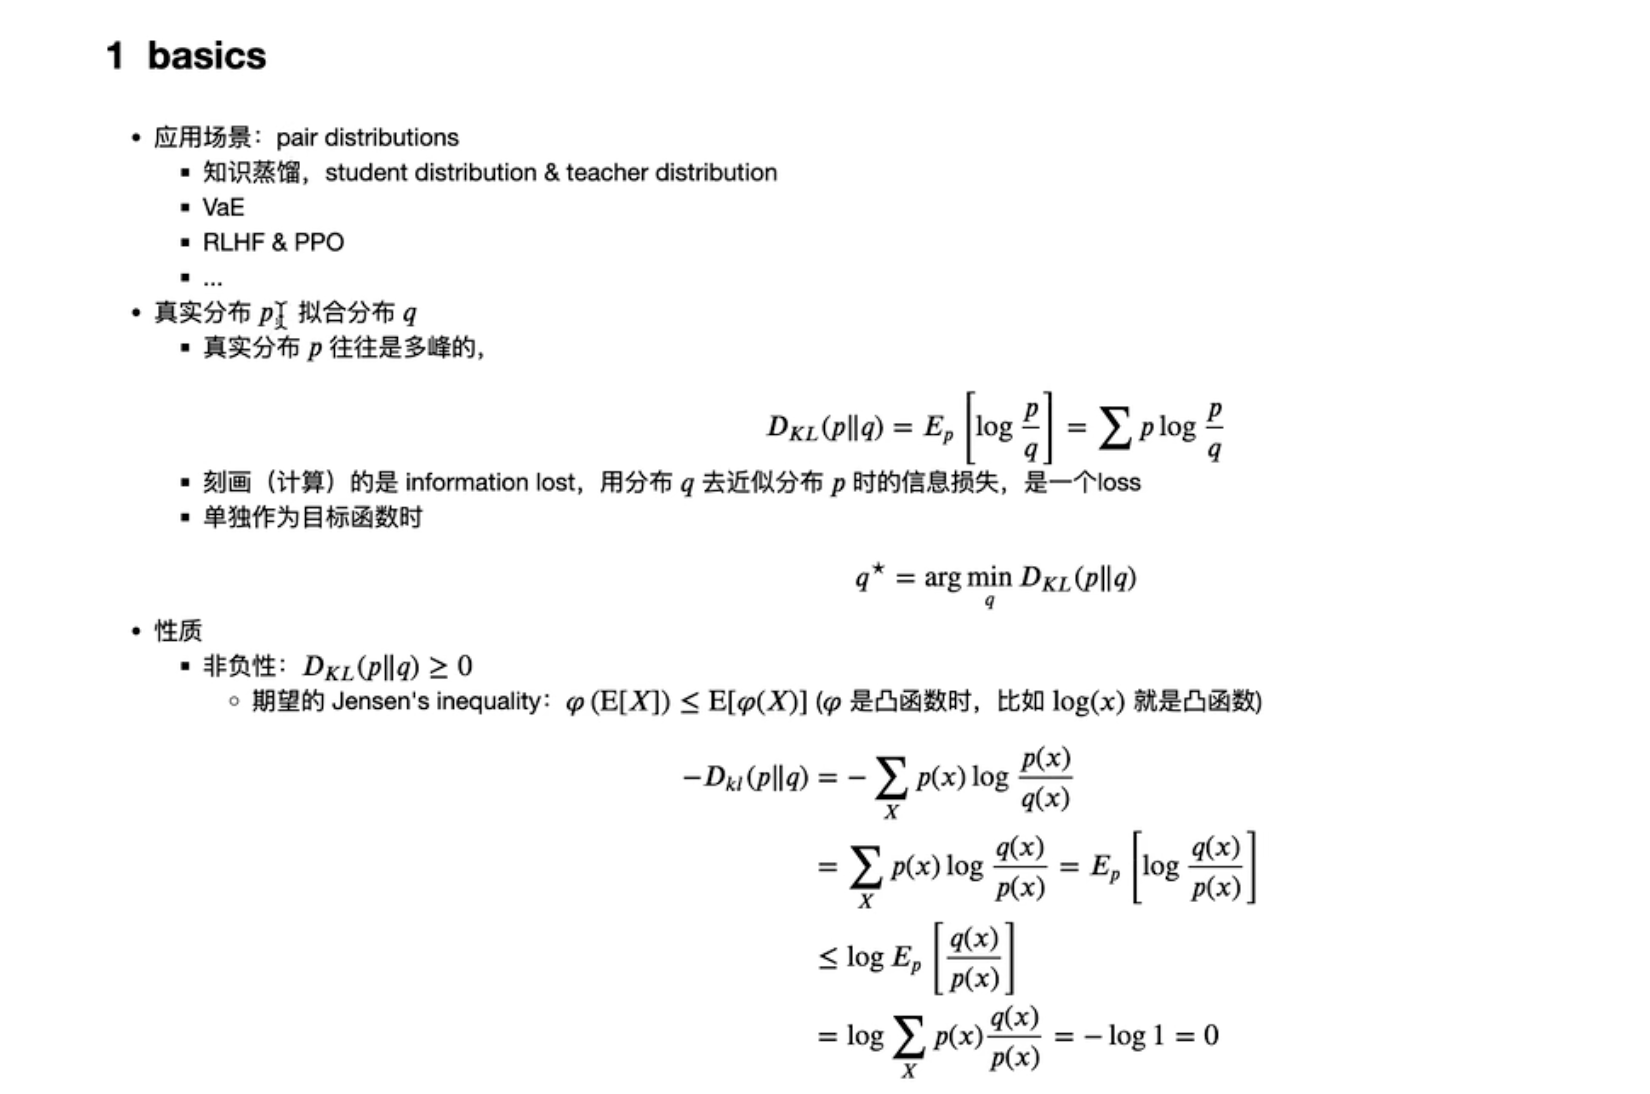

In [1]:
import numpy as np
from scipy.special import kl_div

In [3]:
P=np.array([0.1,0.2,0.7])
Q=np.array([0.3,0.4,0.3])
kl_div(P,Q).sum()

np.float64(0.34461783729224255)

In [4]:
np.sum(P*np.log(P/Q))

np.float64(0.3446178372922425)

# 连续性变量
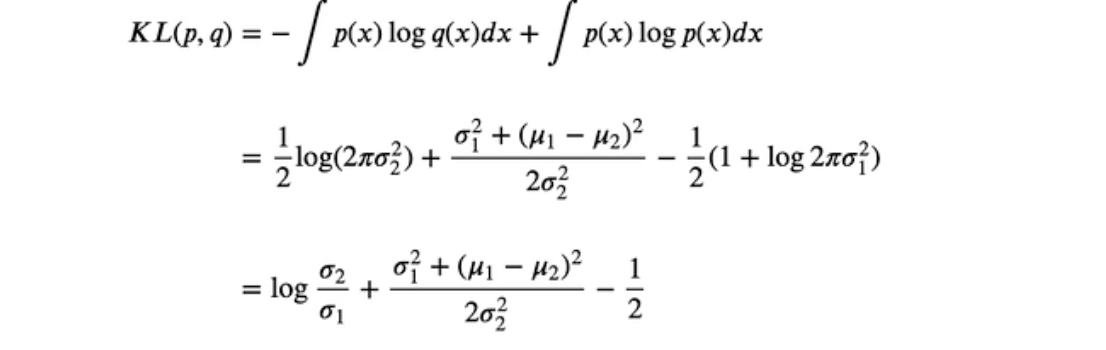

In [6]:
from scipy.stats import norm

In [21]:
scale1=1
scale2=2
mean1=0
mean2=1

In [22]:
P=norm(loc=mean1,scale=scale1)
Q=norm(loc=mean2,scale=scale2)

In [5]:
from scipy.integrate import quad

In [8]:
Q.pdf(-10)

np.float64(5.384880021271638e-08)

In [24]:
import numpy as np
from scipy.integrate import quad

def kl_divergence_continuous(P, Q, lower=-np.inf, upper=np.inf):
    # 增加一个小常数 epsilon 防止 log(0)

    
    def integrand(x):
        p_val = P.pdf(x)
        q_val = Q.pdf(x)
        
        # 如果 P(x) 为 0，该点对 KL 散度的贡献为 0 (极限意义上)
        if p_val <= 0:
            return 0
        
        return p_val * np.log(p_val / (q_val + eps))
    
    # quad 会返回 (积分值, 估计误差)
    result, error = quad(integrand, lower, upper)
    return result

In [25]:
FL_continuous(P,Q,lower=-10,upper=10)

0.44314718055994545

In [26]:
np.log(scale2/scale1)+(scale1**2+(mean1-mean2)**2)/(2*scale2**2)-1/2

np.float64(0.4431471805599453)